## Import

In [1]:
#General
import pandas as pd
import numpy as np
from numpy import std, mean, sqrt
import math
#Statistics
from scipy.stats import mannwhitneyu
#Visualization
from matplotlib import pyplot as plt
import matplotlib
#Utility
from tabulate import tabulate

In [2]:
#Custom imports
from stat_util import normal_test_all_model_samples
from stat_util import t_test_model_samples_against_other_model_samples
from stat_util import cohen_d_test_model_samples_against_other_model_samples

## Dataset preparation

In [3]:
datasets = [
    "JDT_R2_0","JDT_R2_1","JDT_R3_0","JDT_R3_1","JDT_R3_2",
    "PDE_R2_0","PDE_R2_1","PDE_R3_0","PDE_R3_1","PDE_R3_2"
]

In [4]:
main_model_name = "REPDX"

In [16]:
main_df = None

for dataset in datasets:
    print("Analyzing:", dataset)
    results_df = pd.read_csv("results/hr_"+dataset)
    results_df = results_df.assign(Dataset=lambda x: dataset)
    #
    results_df.loc[results_df["Model"]=="OLD_REPD", 'Model'] = "REPD"
    results_df.loc[results_df["Model"]=="REPD_EX", 'Model'] = "REPDX"
    #
    if main_df is None:
        main_df = results_df
    else: 
        main_df = pd.concat([main_df,results_df])

    #
    #print(results_df[results_df["F1 score"]==results_df["F1 score"].max()][["Model","F1 score","Precision","Recall"]])
    #print(results_df[results_df["Precision"]==results_df["Precision"].max()][["Model","F1 score","Precision","Recall"]])
    print(results_df[results_df["Recall"]==results_df["Recall"].max()][["Model","F1 score","Precision","Recall"]])
    #print()
    #
    #group_df = results_df \
    #            .drop(columns=['Accuracy', 'Accuracy base', 'Precision base', 'Recall base', 'F1 base score']) \
    #            .rename(index=str, columns={"F1 score": "F1"}) \
    #            .groupby(["Model"])
    #print(group_df["F1"].median())
    #print(group_df["Precision"].median())
    #print(group_df["Recall"].median())
    print()
    #
    #
    #stat, p = mannwhitneyu(
    #            results_df[results_df["Model"]=="REPDX"]["F1 score"].values, 
    #            results_df[results_df["Model"]=="REPD"]["F1 score"].values
    #            )
    #stat, p = mannwhitneyu(
    #            results_df[results_df["Model"]=="REPDX"]["Precision"].values, 
    #            results_df[results_df["Model"]=="REPD"]["Precision"].values
    #            )
    #stat, p = mannwhitneyu(
    #            results_df[results_df["Model"]=="REPDX"]["Recall"].values, 
    #            results_df[results_df["Model"]=="REPD"]["Recall"].values
    #            )
    #
    #print('Statistics=%.3f, p=%.3f' % (stat, p))
    #print()
    # interpret
    #alpha = 0.05
    #if p > alpha:
    #    print('Same distribution (fail to reject H0)')
    #else:
    #    print('Different distribution (reject H0)')
    #print()
    #print()


Analyzing: JDT_R2_0
     Model  F1 score  Precision    Recall
149  REPDX  0.673993   0.516854  0.968421

Analyzing: JDT_R2_1
     Model  F1 score  Precision    Recall
117  REPDX  0.635379   0.470588  0.977778

Analyzing: JDT_R3_0
     Model  F1 score  Precision    Recall
147  REPDX  0.626943   0.468992  0.945312

Analyzing: JDT_R3_1
     Model  F1 score  Precision    Recall
107  REPDX  0.615385   0.457143  0.941176

Analyzing: JDT_R3_2
     Model  F1 score  Precision    Recall
127  REPDX  0.590308   0.426752  0.957143

Analyzing: PDE_R2_0
     Model  F1 score  Precision  Recall
1    REPDX  0.542373   0.372093     1.0
2     REPD  0.461538   0.300000     1.0
3    REPDX  0.439024   0.281250     1.0
13   REPDX  0.428571   0.272727     1.0
21   REPDX  0.391304   0.243243     1.0
25   REPDX  0.550000   0.379310     1.0
35   REPDX  0.458333   0.297297     1.0
41   REPDX  0.285714   0.166667     1.0
51   REPDX  0.500000   0.333333     1.0
52    REPD  0.461538   0.300000     1.0
53   REPDX  0.4

In [6]:
group_df = main_df.drop(columns=['Accuracy', 'Accuracy base', 'Precision base', 'Recall base', 'F1 base score']).rename(index=str, columns={"F1 score": "F1"}).groupby(["Dataset","Model"])

In [15]:
#print(group_df[["F1"]].median().to_latex())
#print(group_df[["Precision"]].median().to_latex())
print(group_df[["Recall","Precision"]].median().to_latex())



\begin{tabular}{llrr}
\toprule
         &       &    Recall &  Precision \\
Dataset & Model &           &            \\
\midrule
JDT\_R2\_0 & REPD &  0.602907 &   0.638072 \\
         & REPDX &  0.848588 &   0.566766 \\
JDT\_R2\_1 & REPD &  0.689272 &   0.498062 \\
         & REPDX &  0.918505 &   0.450708 \\
JDT\_R3\_0 & REPD &  0.704565 &   0.601724 \\
         & REPDX &  0.885930 &   0.504186 \\
JDT\_R3\_1 & REPD &  0.643529 &   0.526316 \\
         & REPDX &  0.862952 &   0.433396 \\
JDT\_R3\_2 & REPD &  0.639992 &   0.600971 \\
         & REPDX &  0.881579 &   0.485593 \\
PDE\_R2\_0 & REPD &  0.785714 &   0.310345 \\
         & REPDX &  0.923077 &   0.289474 \\
PDE\_R2\_1 & REPD &  0.600000 &   0.250000 \\
         & REPDX &  0.861905 &   0.244173 \\
PDE\_R3\_0 & REPD &  0.650000 &   0.459341 \\
         & REPDX &  0.875000 &   0.392800 \\
PDE\_R3\_1 & REPD &  0.688578 &   0.490381 \\
         & REPDX &  0.888889 &   0.426471 \\
PDE\_R3\_2 & REPD &  0.474993 &   0.584350 \\
      

In [8]:
import seaborn as sns

In [13]:
def plot_measure(measure_name,plot_name):
    df = main_df.drop(columns=['Accuracy', 'Accuracy base', 'Precision base', 'Recall base', 'F1 base score'])
    new_dfs = []

    dataset_list = list(set(df.Dataset.values))
    dataset_list.sort()

    for n, dataset in enumerate(dataset_list):
        new_df = []

        for model in list(set(df.Model.values)):
            f1_scores = []
            temp = df.loc[(df['Dataset'] == dataset) & (df['Model'] == model)][measure_name].values
            for value in temp:
                d = {
                    'DatasetModel' : '{: <26}'.format(", ".join([dataset, model])), measure_name : value
                }
                new_df.append(d)

        new_df = pd.DataFrame(new_df)
        new_dfs.append(new_df)

    #Plotting prepared dataset
    fig, axs = plt.subplots(10, 1, figsize=(64,128), sharex=True, sharey="row", gridspec_kw={'hspace': 0.1})

    font = {'size': 58}
    matplotlib.rc('font', **font)
    for n, new_df in enumerate(new_dfs):
        dataset = dataset_list[n]
        ax=axs[n]
        sns.violinplot(measure_name,'DatasetModel', data=new_df, ax = ax, scale="count", cut=0)
        #
        yax = ax.get_yaxis()
        yax.grid(True)
        yax.set_ticks_position('right')
        pad = max([len(i) for i in new_df['DatasetModel'].values])
        yax.set_tick_params(pad=pad)
        y_label = yax.get_label()
        y_label.set_visible(False)
        #
        xax = ax.get_xaxis()
        xax.grid(True)
        x_label = xax.get_label()
        x_label.set_visible(False)
        #
        ax.set_title("")

    fig.suptitle(measure_name)
    st = fig.suptitle(measure_name, fontsize="x-large")
    st.set_y(0.95)
    fig.subplots_adjust(top=0.93)
    fig.tight_layout()
    plt.tight_layout()
    plt.savefig(plot_name,format='pdf',bbox_inches='tight')
    plt.show()

/home/paf/miniconda3/lib/python3.6/site-packages/matplotlib/figure.py:1999: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "
/home/paf/miniconda3/lib/python3.6/site-packages/matplotlib/figure.py:1999: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


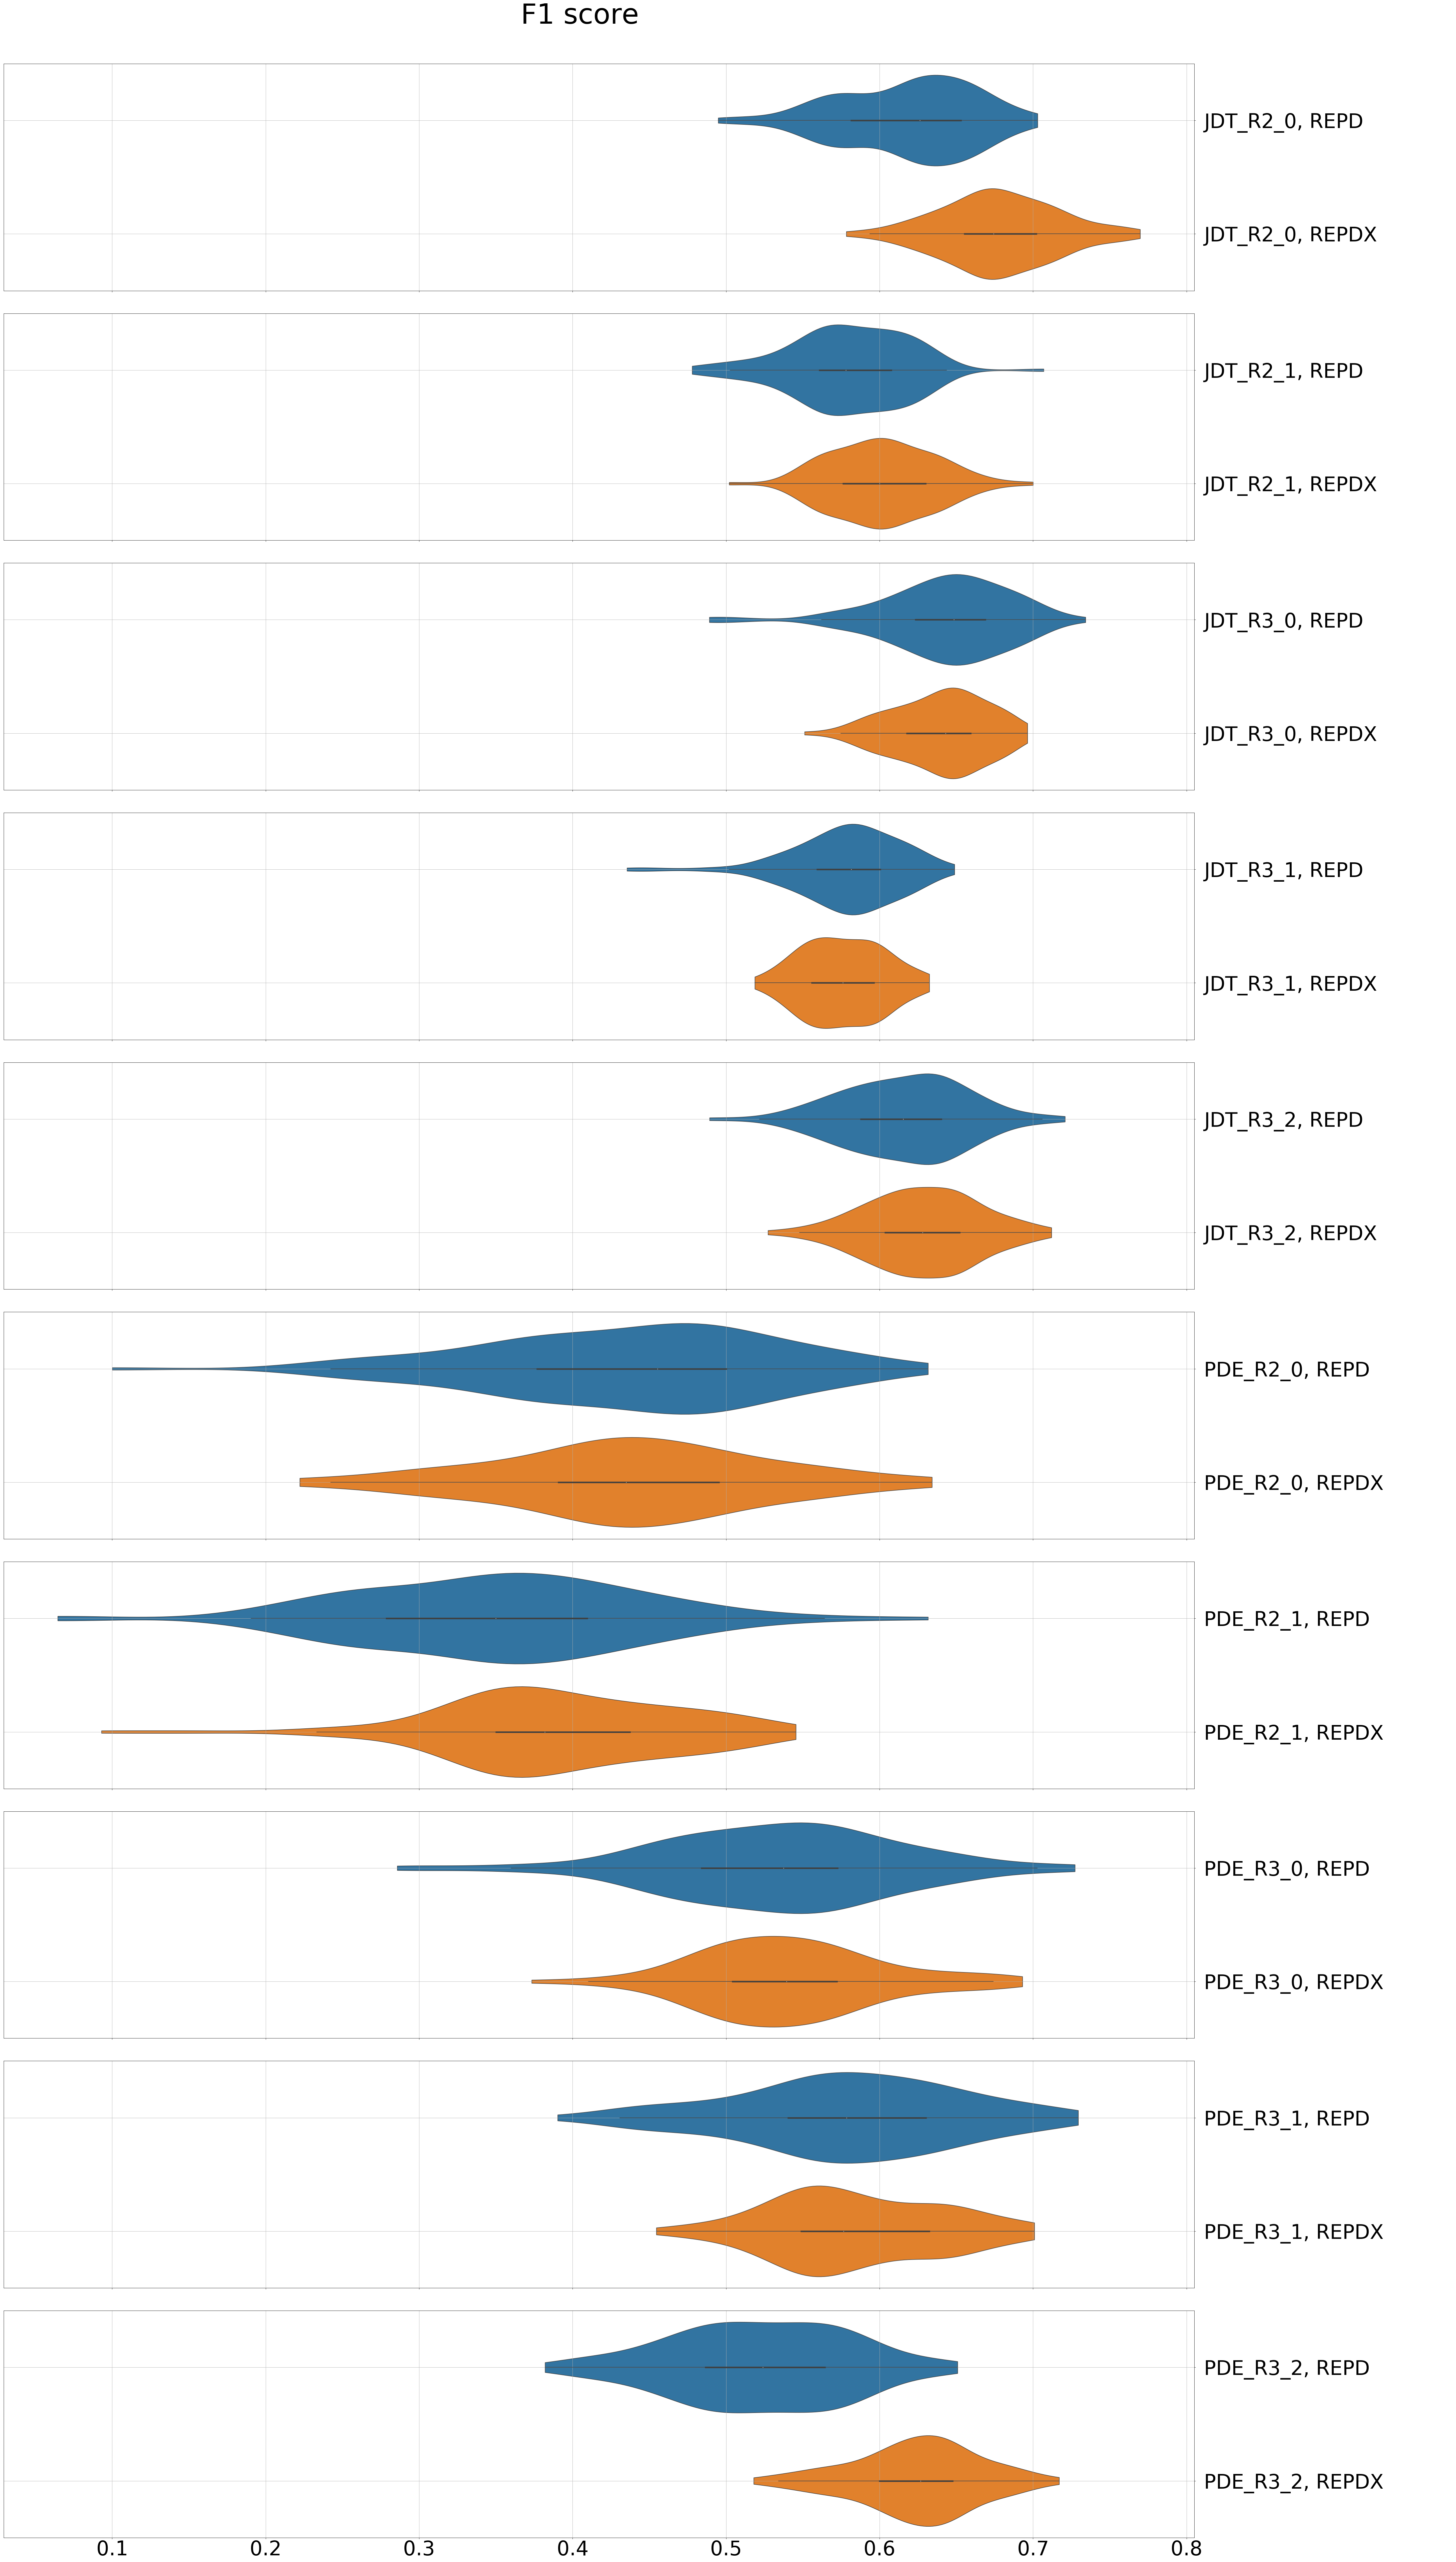

In [14]:
plot_measure("F1 score","wp-hr-f1.pdf")

/home/paf/miniconda3/lib/python3.6/site-packages/matplotlib/figure.py:1999: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "
/home/paf/miniconda3/lib/python3.6/site-packages/matplotlib/figure.py:1999: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


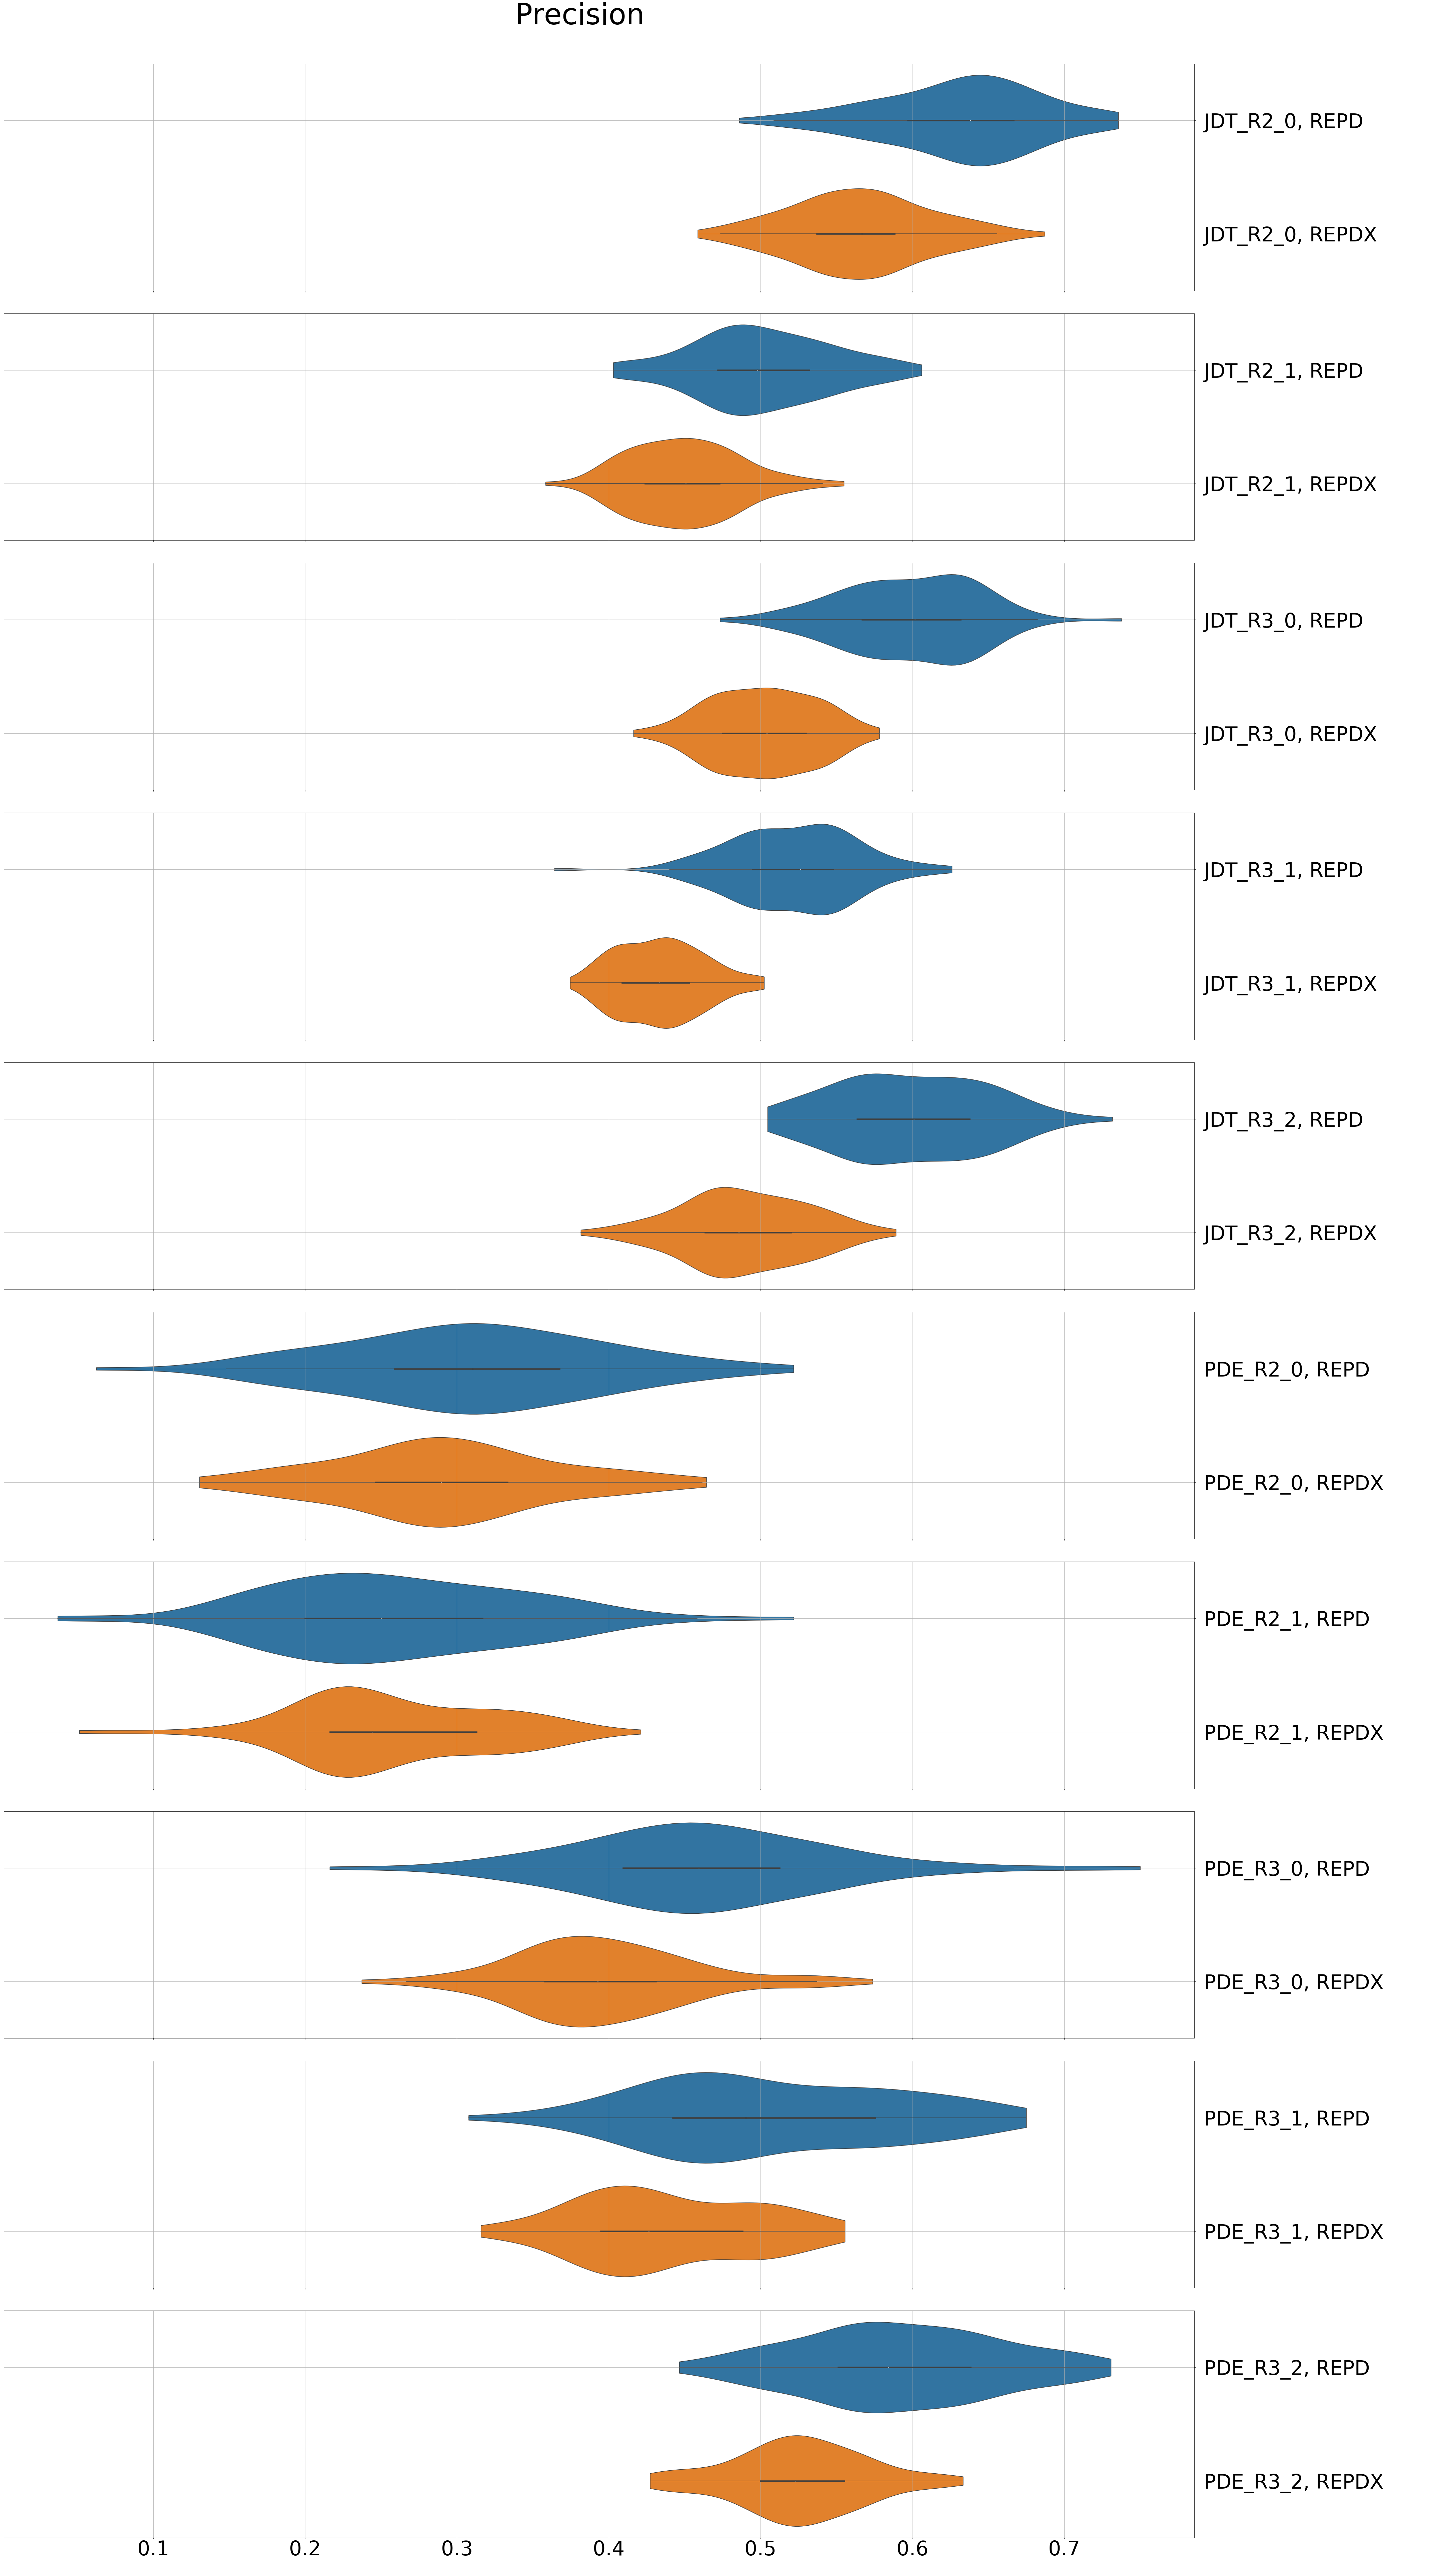

In [11]:
plot_measure("Precision","wp-hr-precision.pdf")

/home/paf/miniconda3/lib/python3.6/site-packages/matplotlib/figure.py:1999: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "
/home/paf/miniconda3/lib/python3.6/site-packages/matplotlib/figure.py:1999: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


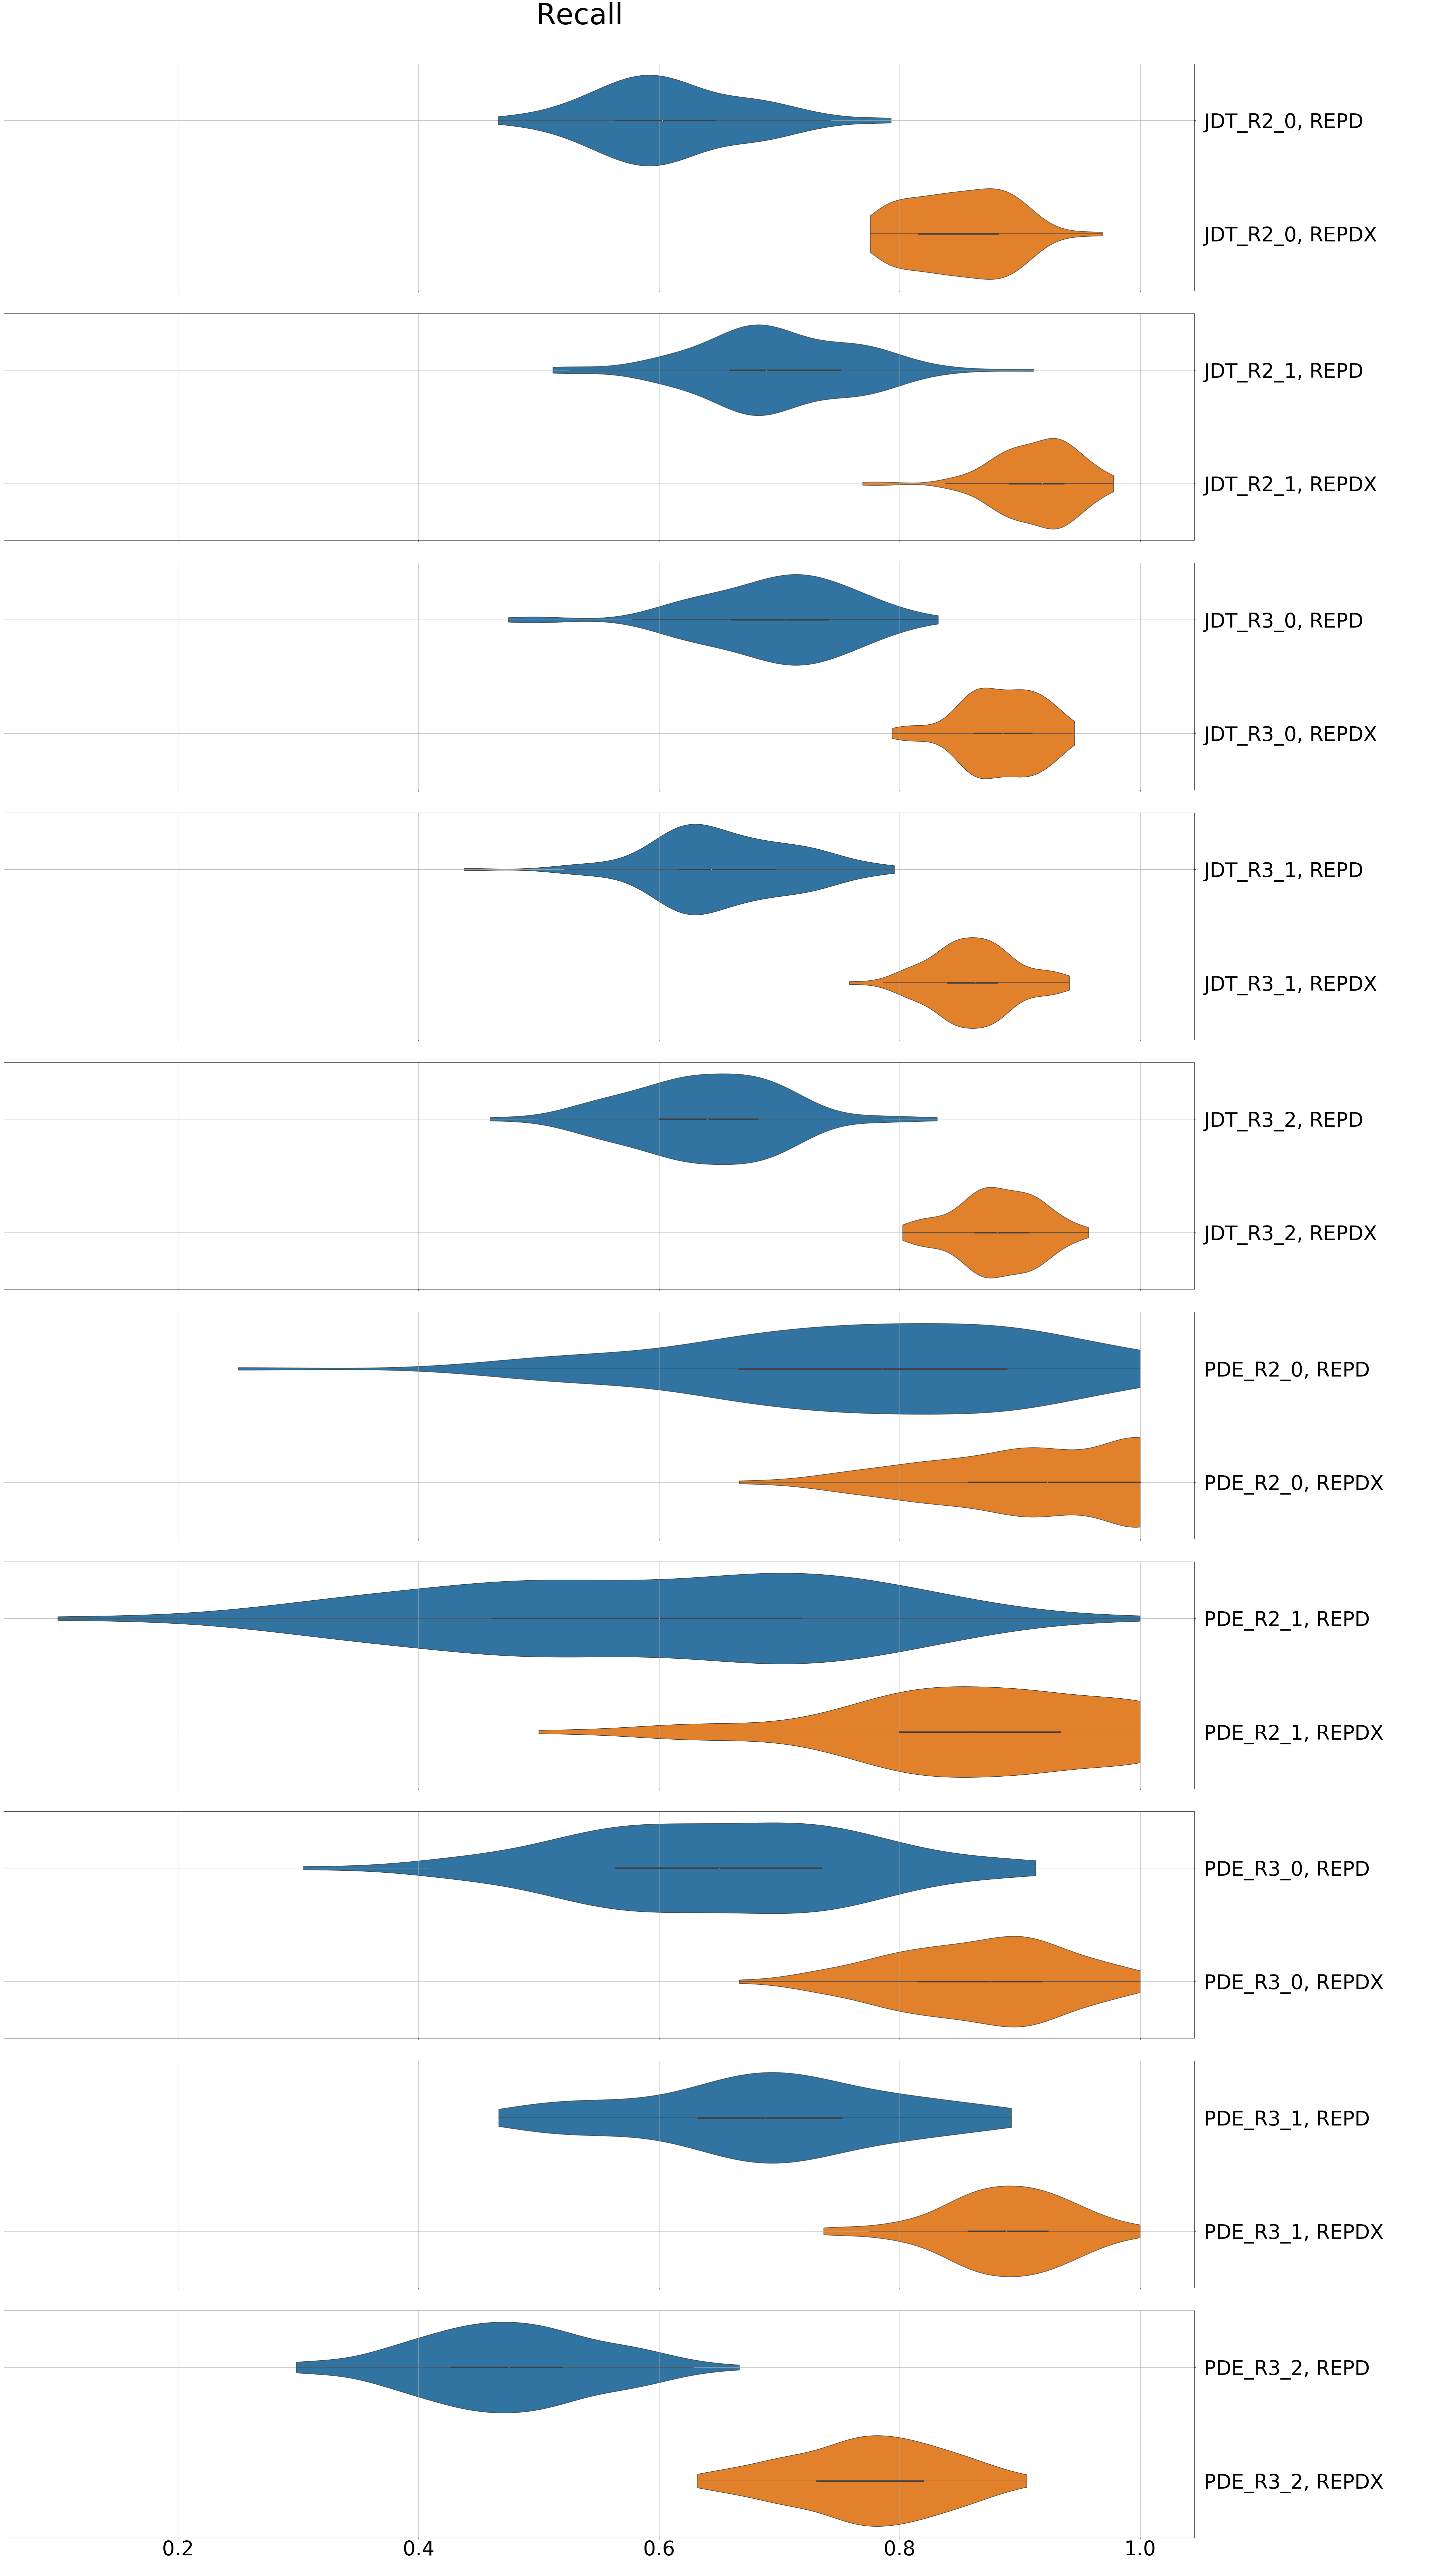

In [12]:
plot_measure("Recall","wp-hr-recall.pdf")